Saving image1.jpg to image1.jpg


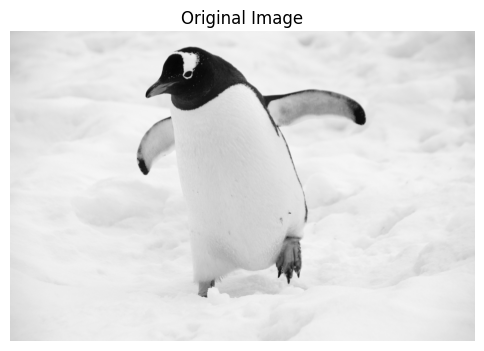

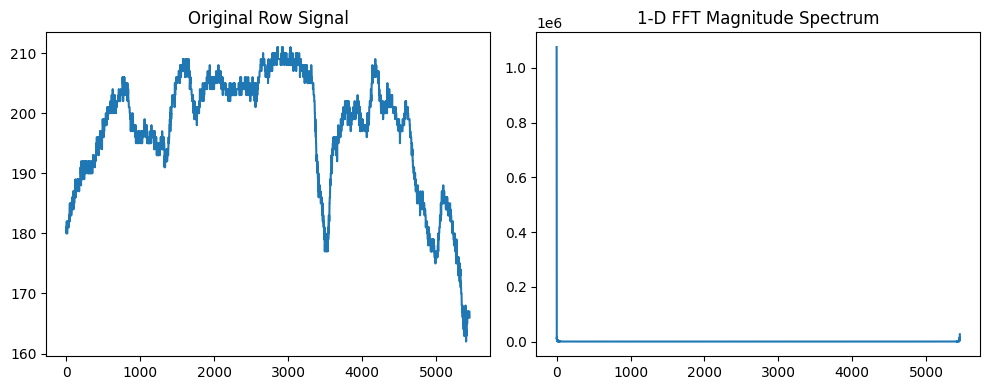

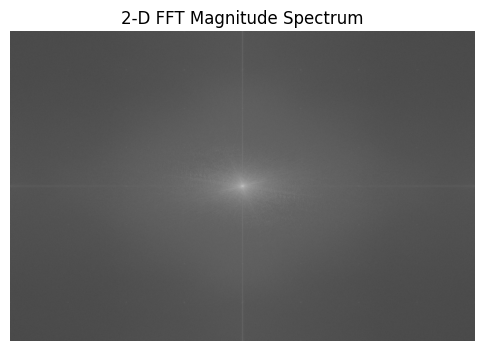

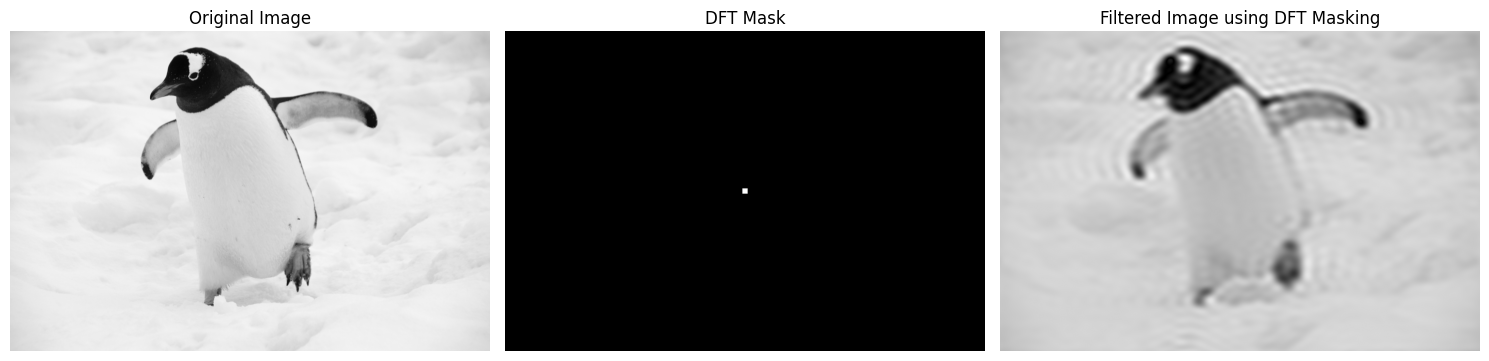

In [ ]:
# =========================================================
# FFT (1-D & 2-D) and DFT Masking on an Image
# =========================================================

# Install libraries
!pip install opencv-python

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# =========================================================
# STEP 1: Upload Image at Runtime
# =========================================================

uploaded = files.upload()

# Get uploaded image name automatically
image_name = list(uploaded.keys())[0]

# Read image in grayscale
img = cv2.imread(image_name, 0)

# =========================================================
# STEP 2: Display Original Image
# =========================================================

plt.figure(figsize=(6,6))
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")
plt.show()

# =========================================================
# STEP 3: 1-D FFT
# =========================================================

# Take one row from image
row_signal = img[100, :]

# Apply 1-D FFT
fft_1d = np.fft.fft(row_signal)

# Magnitude Spectrum
magnitude_1d = np.abs(fft_1d)

# Plot 1-D FFT
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(row_signal)
plt.title("Original Row Signal")

plt.subplot(1,2,2)
plt.plot(magnitude_1d)
plt.title("1-D FFT Magnitude Spectrum")

plt.tight_layout()
plt.show()

# =========================================================
# STEP 4: 2-D FFT using DFT
# =========================================================

# Apply 2-D FFT
dft = np.fft.fft2(img)

# Shift zero frequency to center
dft_shift = np.fft.fftshift(dft)

# Magnitude Spectrum
magnitude_spectrum = 20 * np.log(np.abs(dft_shift) + 1)

# Display magnitude spectrum
plt.figure(figsize=(6,6))
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title("2-D FFT Magnitude Spectrum")
plt.axis("off")
plt.show()

# =========================================================
# STEP 5: Apply DFT Masking (Low Pass Filter)
# =========================================================

rows, cols = img.shape
crow, ccol = rows // 2 , cols // 2

# Create mask
mask = np.zeros((rows, cols), np.uint8)

# Square mask area
mask[crow-30:crow+30, ccol-30:ccol+30] = 1

# Apply mask
filtered_dft = dft_shift * mask

# Inverse shift
inverse_shift = np.fft.ifftshift(filtered_dft)

# Inverse FFT
inverse_fft = np.fft.ifft2(inverse_shift)

# Take magnitude
filtered_image = np.abs(inverse_fft)

# =========================================================
# STEP 6: Display Results
# =========================================================

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask, cmap='gray')
plt.title("DFT Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(filtered_image, cmap='gray')
plt.title("Filtered Image using DFT Masking")
plt.axis("off")

plt.tight_layout()
plt.show()